In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/khushikyad001/public-transport-delays-with-weather-and-events/public_transport_delays.csv



First 5 Rows
  trip_id        date      time transport_type  route_id origin_station  \
0  T00000  2023-01-01  05:00:00           Tram  Route_15     Station_31   
1  T00001  2023-01-01  05:15:00          Metro  Route_12     Station_49   
2  T00002  2023-01-01  05:30:00            Bus  Route_16     Station_29   
3  T00003  2023-01-01  05:45:00           Tram  Route_19     Station_26   
4  T00004  2023-01-01  06:00:00           Tram   Route_8     Station_18   

  destination_station scheduled_departure scheduled_arrival  \
0           Station_6            05:02:00          05:55:00   
1          Station_32            05:16:00          05:55:00   
2          Station_42            05:33:00          06:17:00   
3          Station_18            05:49:00          06:08:00   
4          Station_15            06:00:00          06:35:00   

   actual_departure_delay_min  ...  wind_speed_kmh precipitation_mm  \
0                          12  ...              46             13.0   
1             

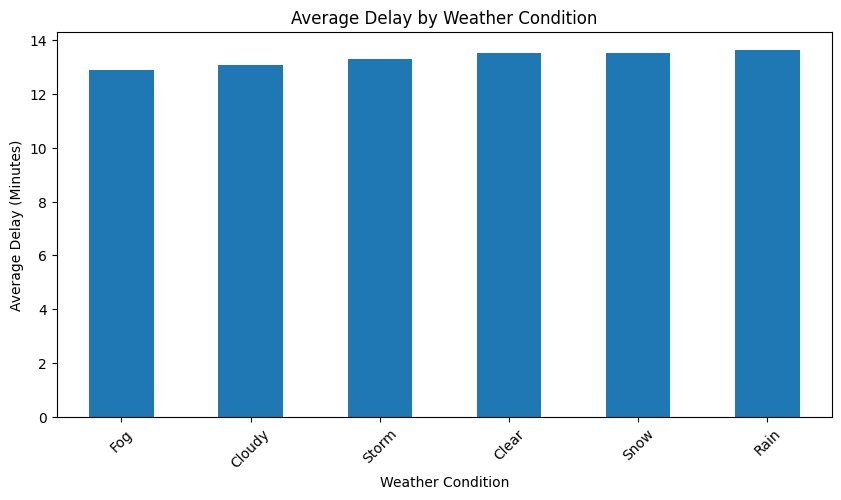

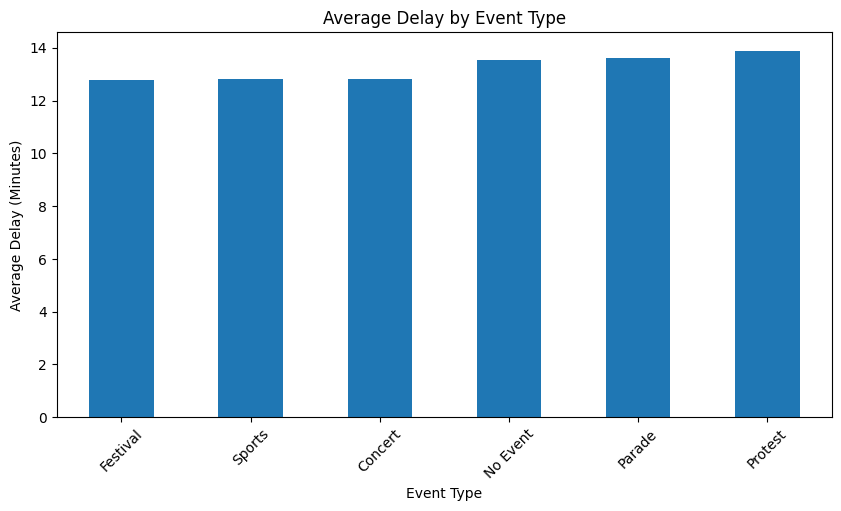

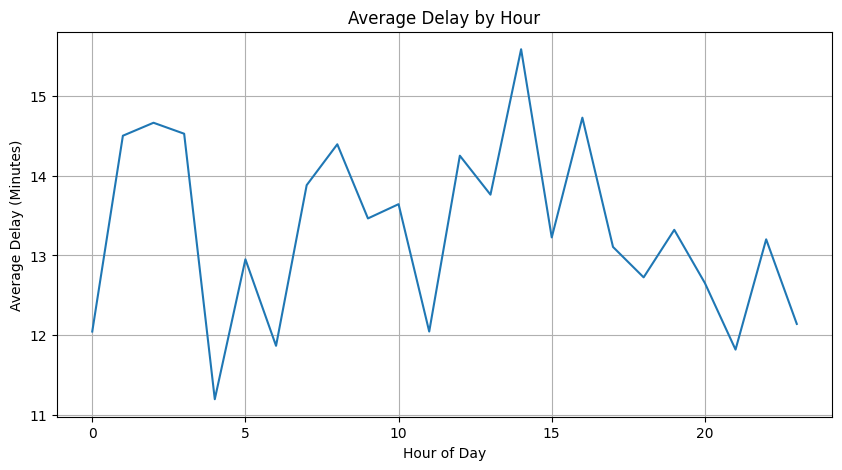

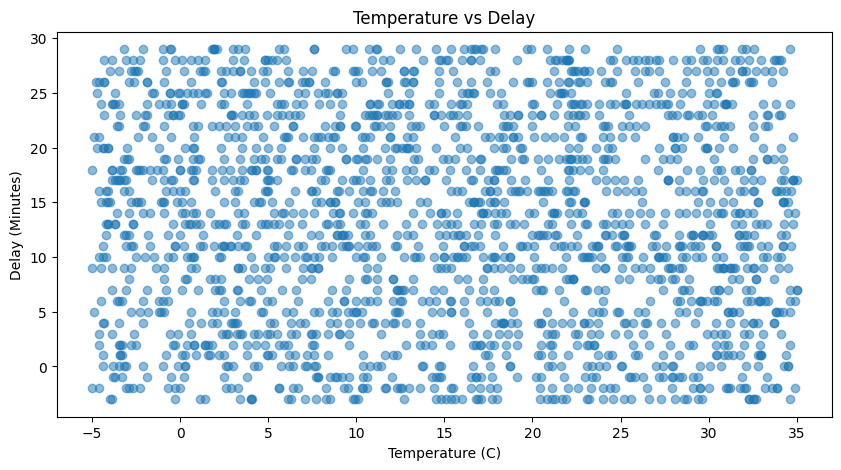

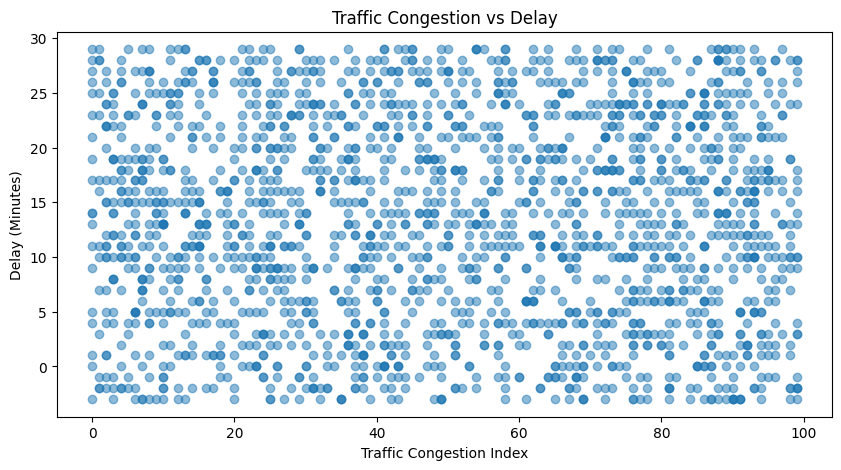


Categorical Columns
Index(['trip_id', 'time', 'transport_type', 'route_id', 'origin_station',
       'destination_station', 'scheduled_departure', 'scheduled_arrival',
       'weather_condition', 'event_type', 'season'],
      dtype='object')


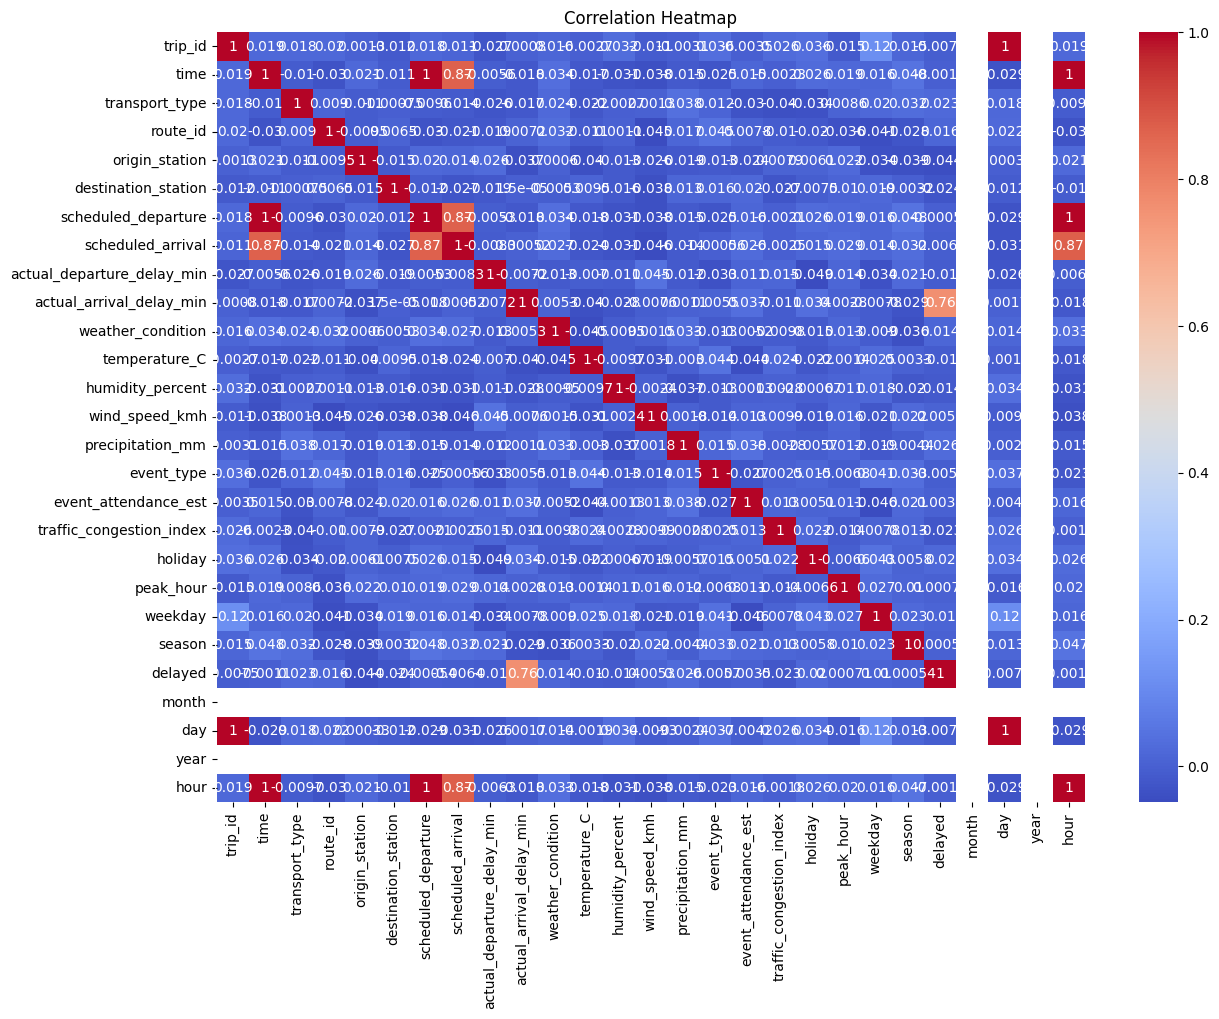


Linear Regression
MAE: 4.635501000926918
RMSE: 5.710475683973899
R2 Score: 0.6132405911388938

Random Forest Results
MAE: 4.698125
RMSE: 5.758320371427765
R2 Score: 0.6067325863112366

Top 10 Important Features
                       Feature  Importance
20                     delayed    0.571670
9                temperature_C    0.036440
12            precipitation_mm    0.034374
15    traffic_congestion_index    0.032994
10            humidity_percent    0.031656
3               origin_station    0.029647
11              wind_speed_kmh    0.029498
4          destination_station    0.029376
2                     route_id    0.024012
7   actual_departure_delay_min    0.023925


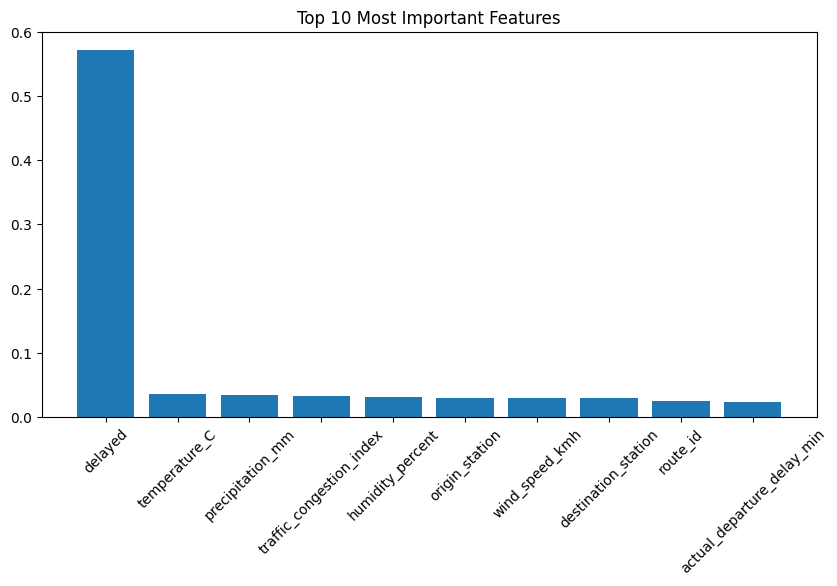

In [13]:
# ============================================================
# Public Transport Delay Prediction using Weather & Events
# ============================================================

# ----------------------------------------------------
# 1. Import Libraries
# ----------------------------------------------------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (

mean_absolute_error,
mean_squared_error,
r2_score
)

In [ ]:
# -------------------------------------
# 2. Load Dataset
# ------------------------------------

df = pd.read_csv(
    "/kaggle/input/datasets/khushikyad001/public-transport-delays-with-weather-and-events/public_transport_delays.csv"
)

print("\nFirst 5 Rows")
print(df.head())


In [15]:

# ------------------------
# 3. Data Understanding
# ------------------------

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe())


Dataset Shape
(2000, 28)

Column Names
Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed', 'month', 'day', 'year',
       'hour'],
      dtype='object')

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trip_id                     2000 non-null   int64         
 1   date                        2000 non-null   datetime64[ns]
 2   time                        2000 non-null   int64   

In [14]:
# ------------------------
# 4. Check Missing Values
# ------------------------

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
trip_id                       0
date                          0
time                          0
transport_type                0
route_id                      0
origin_station                0
destination_station           0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
weather_condition             0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_type                    0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
season                        0
delayed                       0
month                         0
day                           0
year                          0
hour                          0
dtype: int64


In [18]:

# -------------------------
# 5. Handle Missing Values
# --------------------------

df["event_type"] = df["event_type"].fillna("No Event")

In [ ]:
# ----------------------------
# 6. Feature Engineering
# ----------------------------

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Create date-based features
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["year"] = df["date"].dt.year

# Extract hour from time column
df["hour"] = pd.to_datetime(
    df["time"],
    format="%H:%M:%S"
).dt.hour

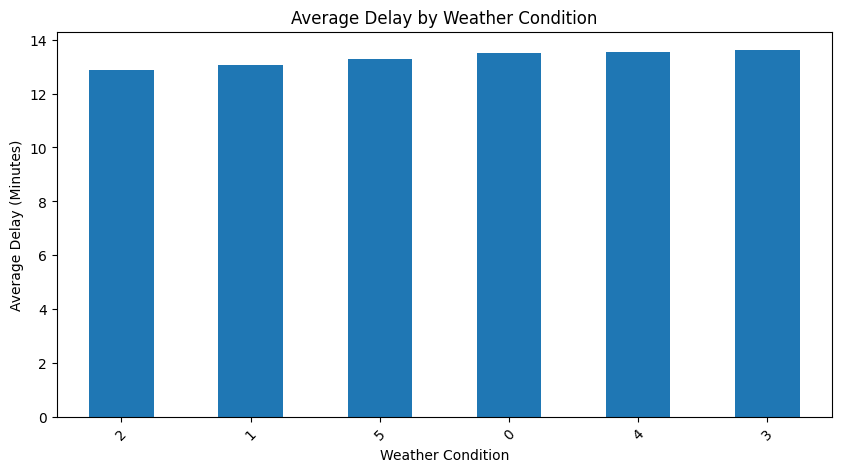

In [19]:
# --------------------
# 7. Visualization
# Weather vs Delay
# ----------------------------

weather_delay = df.groupby(
    "weather_condition"
)["actual_arrival_delay_min"].mean()

plt.figure(figsize=(10,5))

weather_delay.sort_values().plot(kind="bar")

plt.title("Average Delay by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delay (Minutes)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
# -------------------------------------------
# 8. Visualization
# Event Vs Delay
# --------------------------------------------
event_delay = df.groupby(
    "event_type"
)["actual_arrival_delay_min"].mean()

plt.figure(figsize=(10, 5))

event_delay.sort_values().plot(kind="bar")

plt.title("Average Delay by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Delay (Minutes)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ---------------------------------
# 9. Visualization
# Delay by Hour
# ----------------------------------

hour_delay = df.groupby(
    "hour"
)["actual_arrival_delay_min"].mean()

plt.figure(figsize=(10,5))

hour_delay.plot()

plt.title("Average Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (Minutes)")

plt.grid(True)

plt.show()

In [ ]:
# -----------------------------
#10. Visualization
# Temperature vs Delay
# -----------------------------
plt.figure(figsize=(10,5))

plt.scatter(
    df["temperature_C"],
    df["actual_arrival_delay_min"],
    alpha=0.5
)

plt.title("Temperature vs Delay")
plt.xlabel("Temperature (C)")
plt.ylabel("Delay (Minutes)")

plt.show()

In [ ]:
# ------------------------------
# 11. Visualization
# Traffic vs Delay
# -------------------------------

plt.figure(figsize=(10,5))

plt.scatter(
    df["traffic_congestion_index"],
    df["actual_arrival_delay_min"],
    alpha=0.5
)

plt.title("Traffic Congestion vs Delay")
plt.xlabel("Traffic Congestion Index")
plt.ylabel("Delay (Minutes)")

plt.show()

In [ ]:
# -----------------------------------------
# 12. Encode Categorical Variables
# -----------------------------------------
cat_cols = df.select_dtypes(
    include=["object", "string"]
).columns

print("\nCategorical Columns")
print(cat_cols)

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
# ----------------------------------------
# 13. Correlation Heatmap
# ----------------------------------------

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# -------------------------------------------
# 14. Define Features & Target
# -------------------------------------------

X = df.drop(
    ["actual_arrival_delay_min", "trip_id", "date"],
    axis=1
)
y = df["actual_arrival_delay_min"]

In [ ]:
# ----------------------------------------
# 15. Train/Test split
# ----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
# -------------------------------------------
# 16. Linear Regression Model
# --------------------------------------------
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [23]:
# ----------------------------------------------
# 17. Evaluate Linear Regression
# -----------------------------------------------

print("\nLinear Regression")

print(
    "MAE:",
    mean_absolute_error(y_test, lr_preds)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, lr_preds))
)

print(
    "R2 Score:",
    r2_score(y_test, lr_preds)
)


Linear Regression
MAE: 4.635501000926918
RMSE: 5.710475683973899
R2 Score: 0.6132405911388938


In [22]:
# --------------------------------------------
# 18. Random Forest Model
# --------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)


In [21]:
# ------------------------------------------------
# 19. Evaluate Random Forest
# -------------------------------------------------

print("\nRandom Forest Results")

print(
    "MAE:",
    mean_absolute_error(y_test, rf_preds)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, rf_preds))
)

print(
    "R2 Score:",
    r2_score(y_test, rf_preds)
)


Random Forest Results
MAE: 4.698125
RMSE: 5.758320371427765
R2 Score: 0.6067325863112366



Top 10 Important Features
                       Feature  Importance
20                     delayed    0.571670
9                temperature_C    0.036440
12            precipitation_mm    0.034374
15    traffic_congestion_index    0.032994
10            humidity_percent    0.031656
3               origin_station    0.029647
11              wind_speed_kmh    0.029498
4          destination_station    0.029376
2                     route_id    0.024012
7   actual_departure_delay_min    0.023925


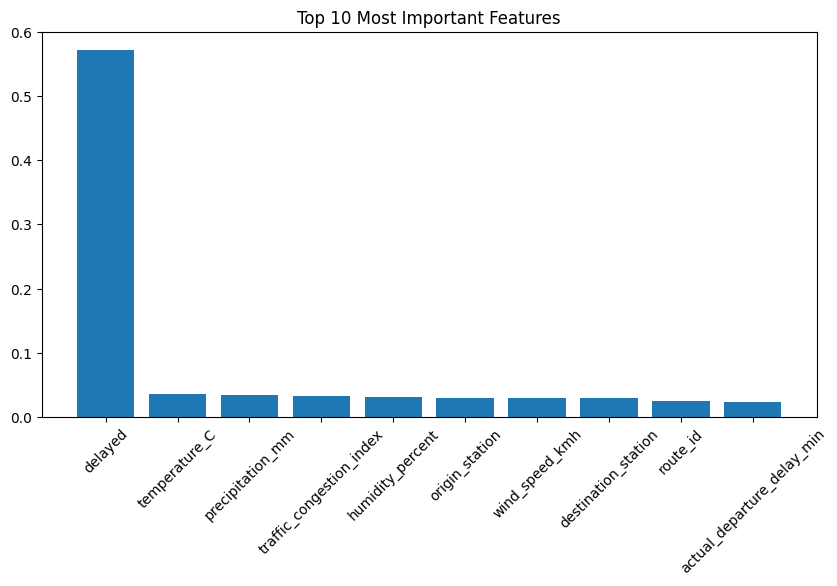

In [20]:
# ---------------------------
# 20. Feature Importance
# ---------------------------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")
print(importance_df.head(10))

# ------------------------------------------
# 21. Feature Importance Visualization
# -------------------------------------------

top_features = importance_df.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Most Important Features")

plt.show()
